**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana7"
os.chdir(DIR)
cars_df = pd.read_csv('automobile_dataset.csv')

Mounted at /content/drive


In [3]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

Númericas: 11, Texto: 15

In [4]:
cars_df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
(cars_df.astype(str) == '?').sum().sort_values(ascending=False)[(cars_df.astype(str) == '?').sum() > 0]

,0
normalized_losses,41
stroke,4
price,4
bore,4
horsepower,2
peak_rpm,2


In [6]:
cars_df = cars_df.replace('?', np.nan)
print(cars_df.isna().sum()[cars_df.isna().sum() > 0])
print('\n' + '-' * 50)
print(cars_df.info())

normalized_losses    41
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height   

In [7]:
cars_df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [8]:
cars_df['normalized_losses'] = pd.to_numeric(cars_df['normalized_losses'], errors='coerce')
cars_df['stroke'] = pd.to_numeric(cars_df['stroke'], errors='coerce')
cars_df['price'] = pd.to_numeric(cars_df['price'], errors='coerce')
cars_df['bore'] = pd.to_numeric(cars_df['bore'], errors='coerce')

In [9]:
cars_df['horsepower'] = cars_df['horsepower'].astype('Int64')
cars_df['peak_rpm'] = cars_df['peak_rpm'].astype('Int64')

In [10]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [11]:
cars_df.duplicated().sum()

np.int64(0)

In [12]:
(cars_df.isna().sum() / len(cars_df) * 100).sort_values(ascending=False)

,0
normalized_losses,20.00000
stroke,1.95122
price,1.95122
bore,1.95122
horsepower,0.97561
peak_rpm,0.97561
make,0.00000
fuel_type,0.00000
aspiration,0.00000
symboling,0.00000


In [13]:
num_cols = cars_df.select_dtypes(include = ['Int64', 'int64', 'float64']).columns.tolist()
cat_cols = cars_df.select_dtypes(include = ['object']).columns.tolist()

In [14]:
#estadisticas descritivas variables numericas
pd.concat([cars_df[num_cols].describe().T, cars_df[num_cols].kurt().rename('curtosis'), cars_df[num_cols].skew().rename('simetria')], axis=1)

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0,-0.676271,0.211072
normalized_losses,164.0,122.0,35.442168,65.0,94.0,115.0,150.0,256.0,0.52544,0.765976
wheel_base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9,1.017039,1.050214
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1,-0.082895,0.155954
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3,0.702764,0.904003
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8,-0.443812,0.063123
curb_weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0,-0.042854,0.681398
num_cylinders,205.0,4.380488,1.080854,2.0,4.0,4.0,4.0,12.0,13.714866,2.817459
engine_size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0,5.305682,1.947655
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94,-0.828945,0.020016


In [15]:
#estadisticas descriptivas variables objeto
cars_df[cat_cols].describe(include = ['object']).T

,count,unique,top,freq
make,205,22,toyota,32
fuel_type,205,2,gas,185
aspiration,205,2,std,168
num_doors,205,2,four,116
body_style,205,5,sedan,96
drive_wheels,205,3,fwd,120
engine_location,205,2,front,202
engine_type,205,7,ohc,148
fuel_system,205,8,mpfi,94


In [16]:
for column in cat_cols:
    print(cars_df[column].value_counts())
    print('-' * 50)

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64
--------------------------------------------------
fuel_type
gas       185
diesel     20
Name: count, dtype: int64
--------------------------------------------------
aspiration
std      168
turbo     37
Name: count, dtype: int64
--------------------------------------------------
num_doors
four    116
two      89
Name: count, dtype: int64
--------------------------------------------------
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
-----------

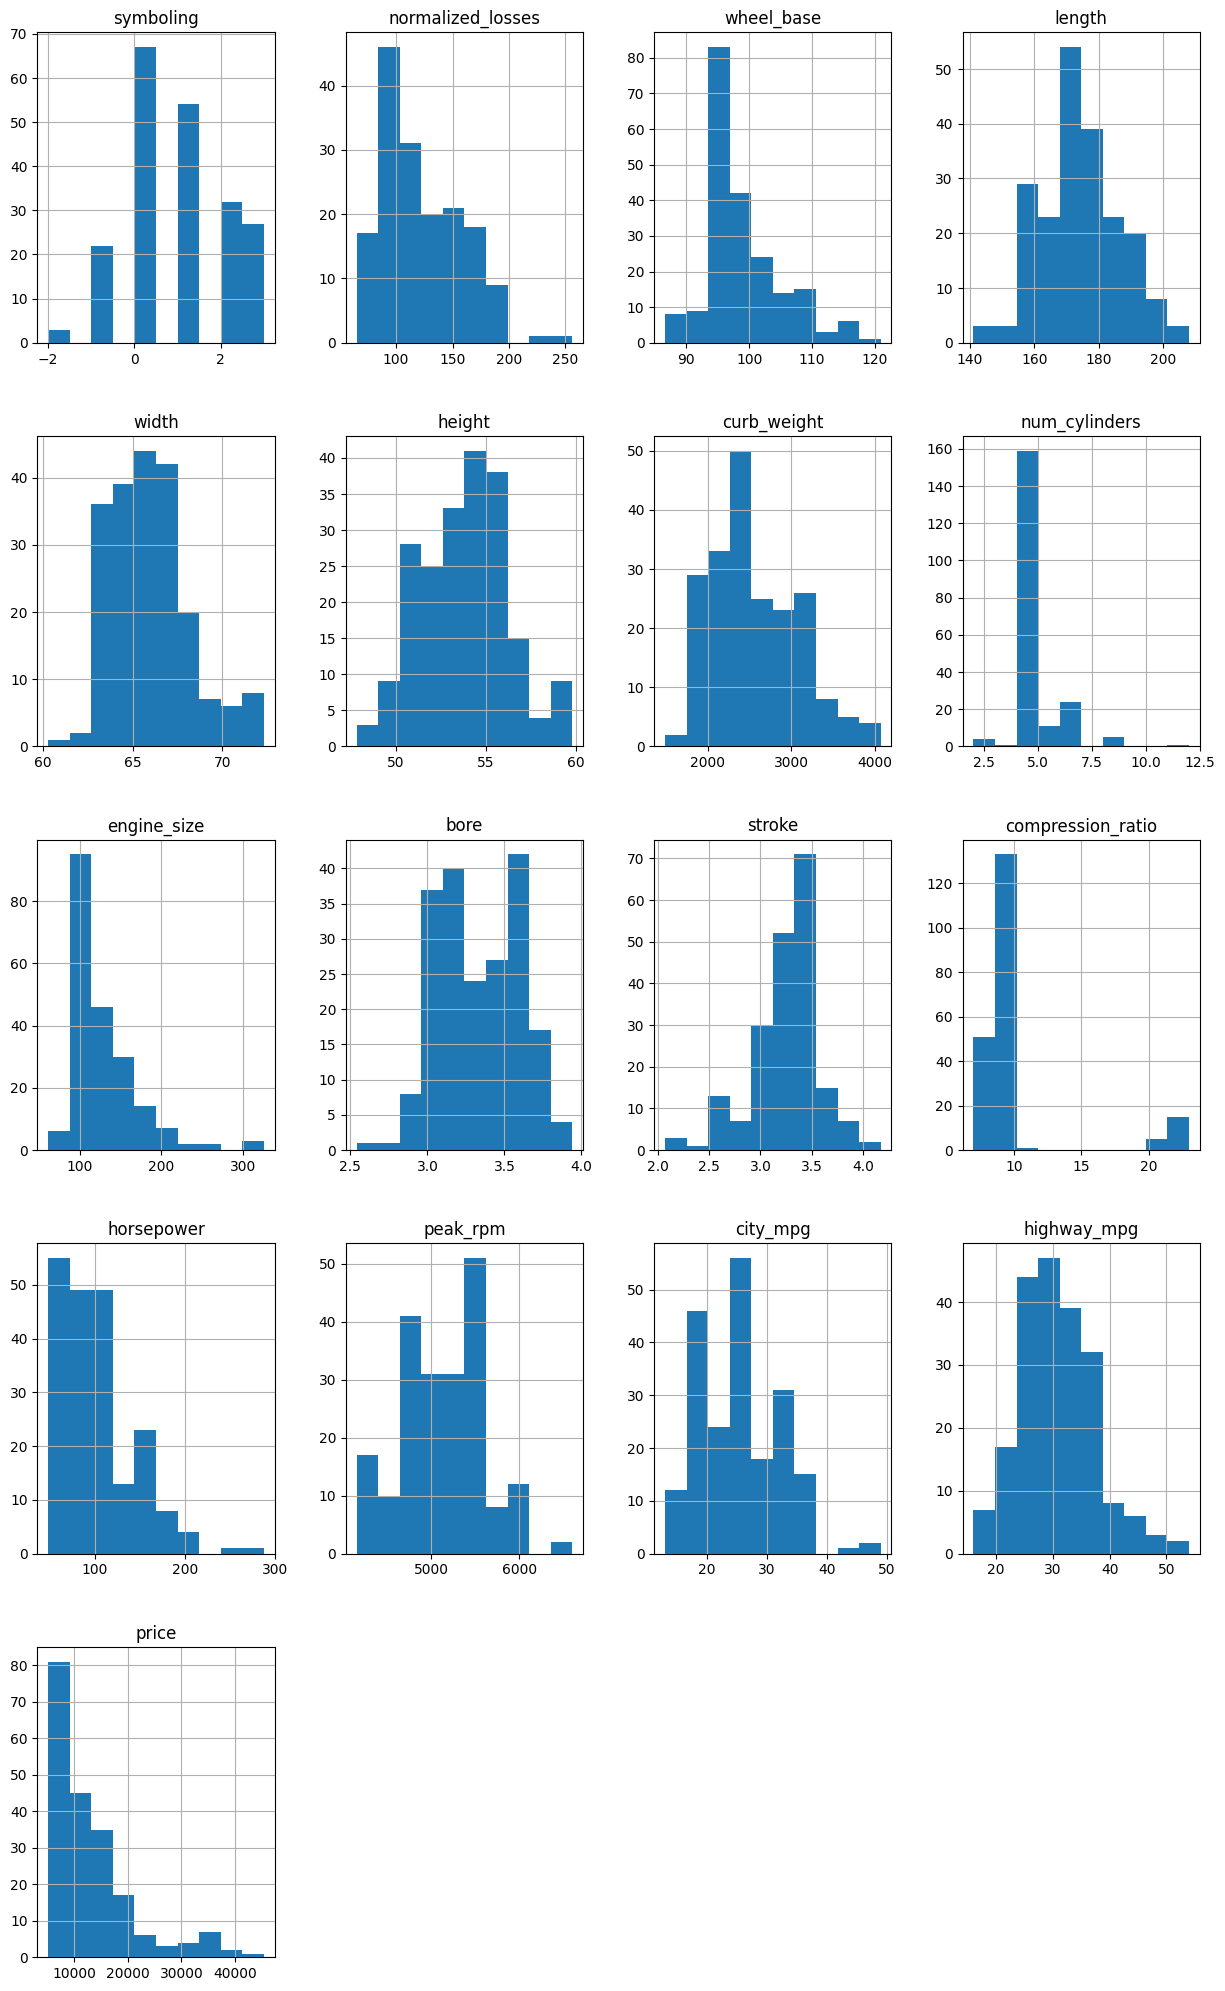

In [17]:
cars_df[num_cols].hist(figsize=(15,25))
plt.show()

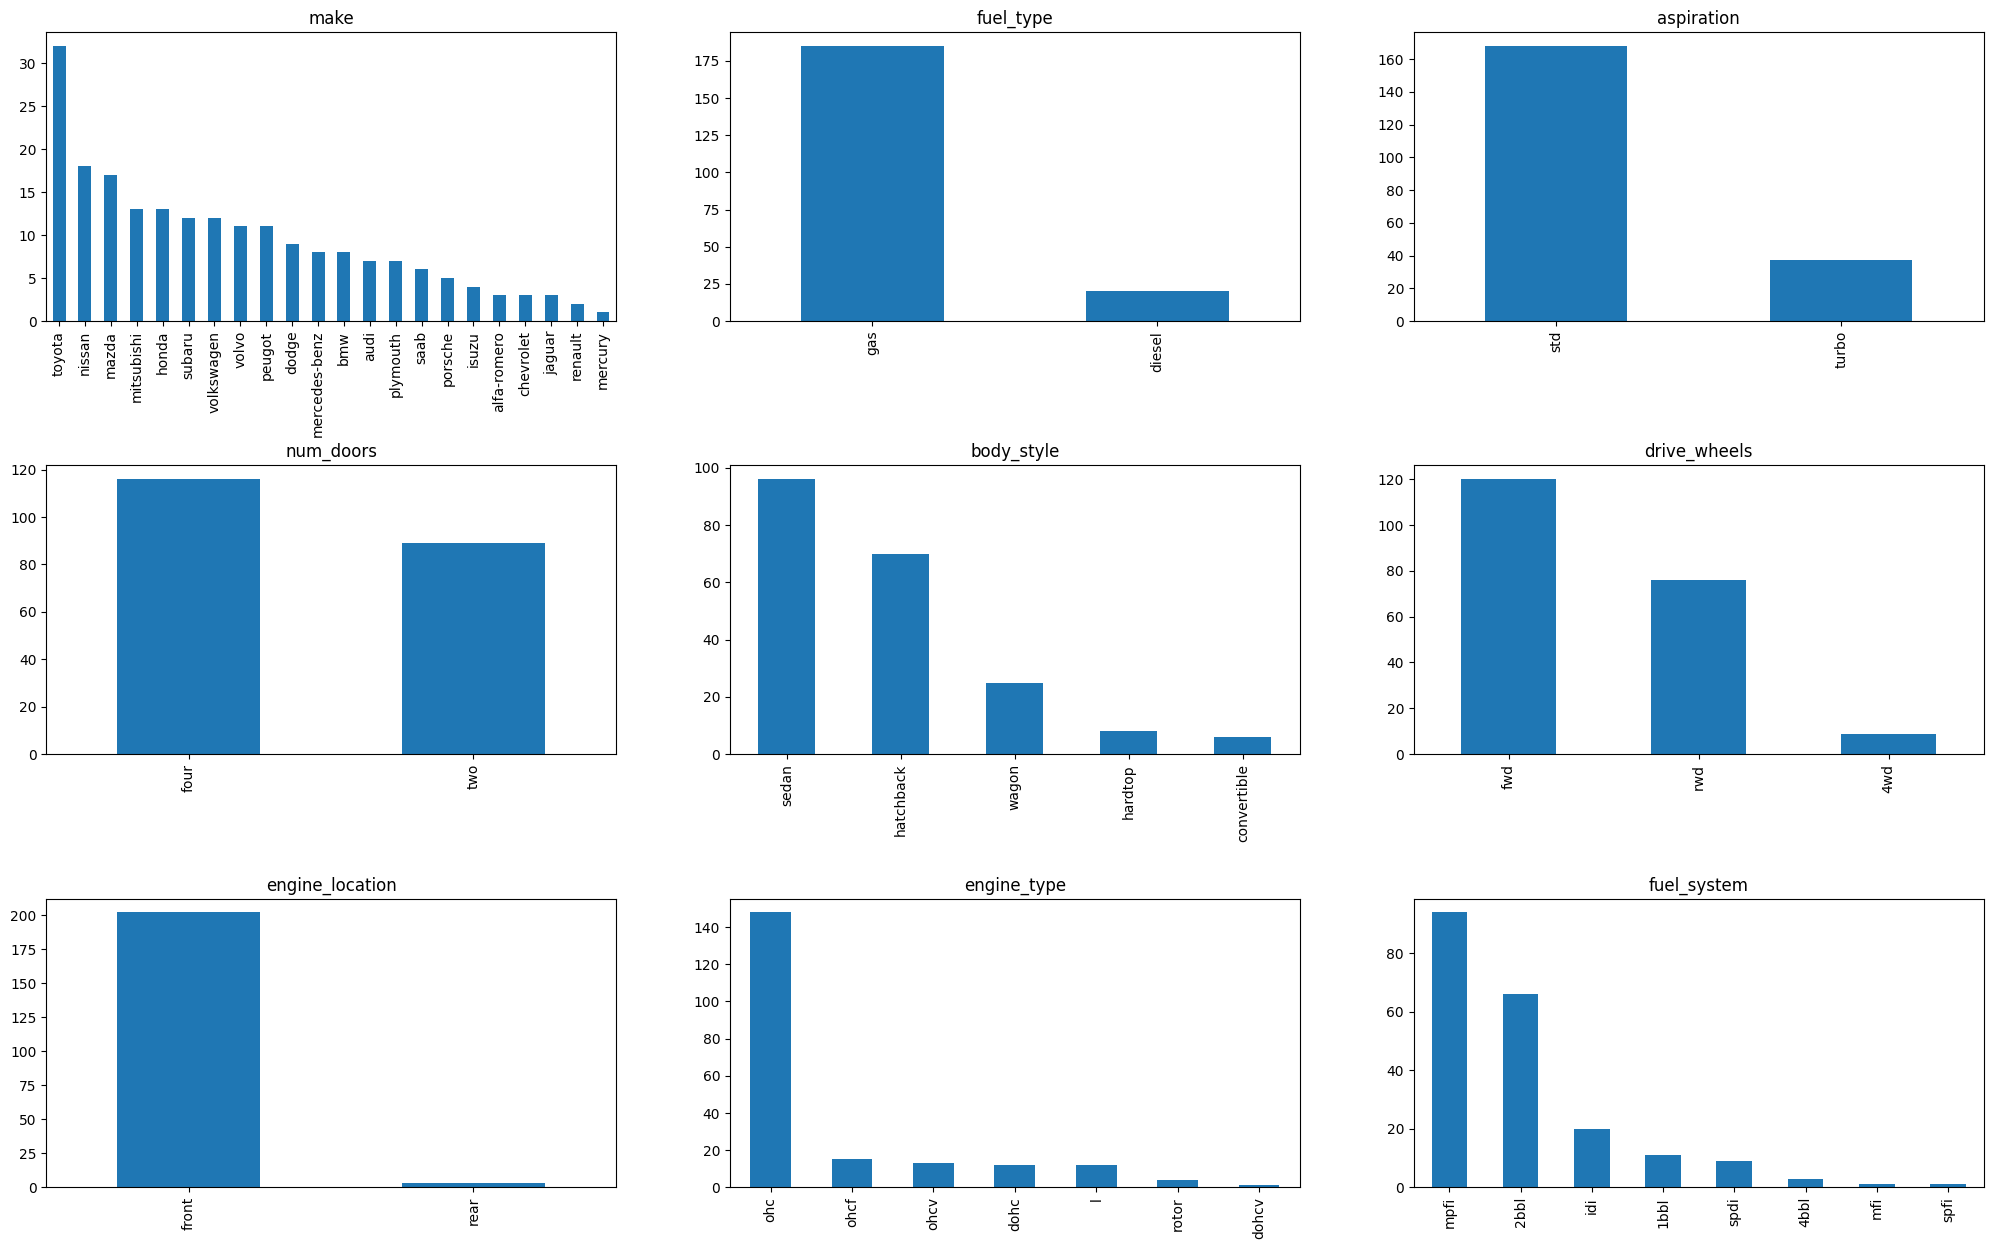

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(25,15))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for col, ax in zip(cars_df[cat_cols], axes):
  cars_df[col].value_counts().plot(kind='bar', ax=ax)
  ax.set(title=f'{col}', xlabel=None)

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

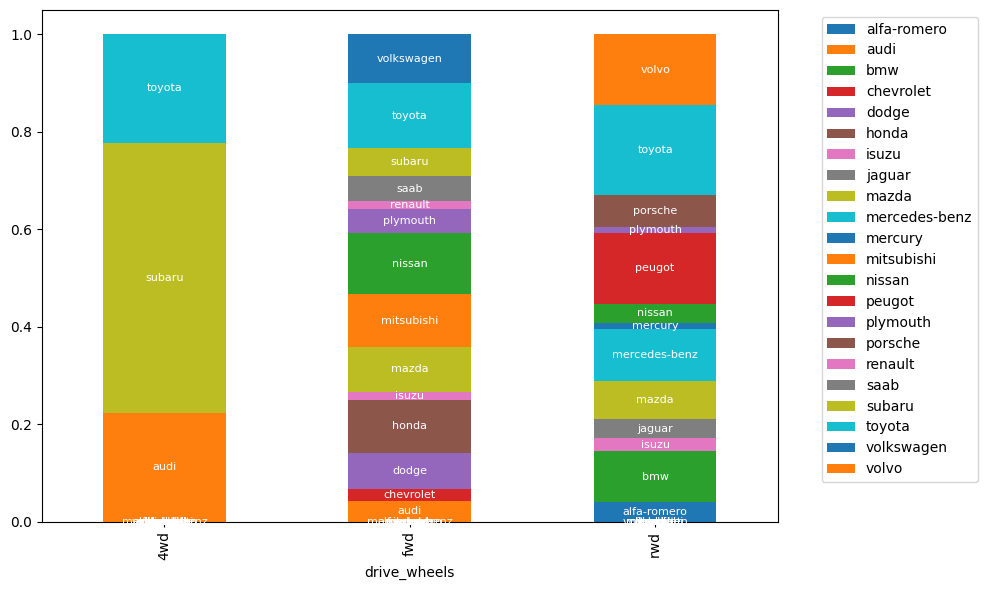

In [19]:
contingency_tab = pd.crosstab(cars_df['drive_wheels'], cars_df['make'], normalize='index')
ax = contingency_tab.plot(kind='bar', stacked=True, figsize=(10,6))


for container, col in zip(ax.containers, contingency_tab.columns):
    ax.bar_label(container, labels=[col]*len(container), label_type='center', fontsize=8, color='white')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Pocos fabricantes hacen automoviles con traccion en las 4 ruedas y está dominado por 3 empresas: Toyota, Subaru y Audi. En cuanto a la traccion delantera, varios fabricantes elaboran automoviles de este tipo, siendo los principales: Toyota, Honda, Nissan, Mazda, Mitsubishi y Volkswagen. Por último, los automoviles con traccion trasera son fabricados por varias empresas como Toyota, Volvo, BMW y Peugot.**

<Axes: xlabel='price', ylabel='body_style'>

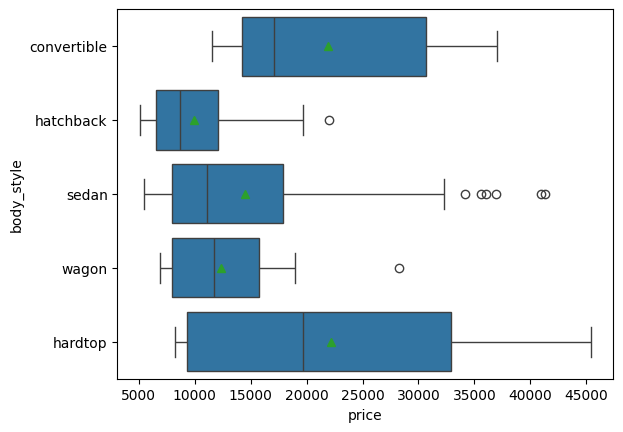

In [20]:
sns.boxplot(x='price', y='body_style', data = cars_df, showmeans=True)

**Los convertibles muestran los precios más altos. Mientras que los hatchbacks y wagons tienen los precios mas concentrados y, relativamente, económicos. Los vehiculos tipo sedan reflejan una amplia variedad de precios desde muy economicos hasta precios muy altos. Por último, los hardtop presentan un variado rango de precios, con precio medio casi al nivel de los convertibles.**

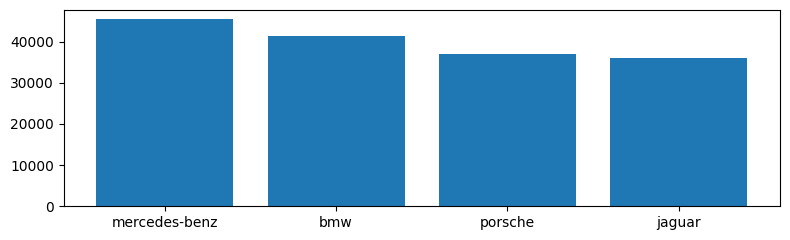

In [21]:
top_10 = cars_df.nlargest(10, 'price')
plt.figure(figsize=(8, 2.5))
plt.bar(top_10['make'].astype(str), top_10['price'])
plt.tight_layout()
plt.show()

**Se observa que los 10 automoviles mas caros pertenecen solamente a 4 fabricantes: Mercedes-Benz, BMW, Porshe y Jaguar.**

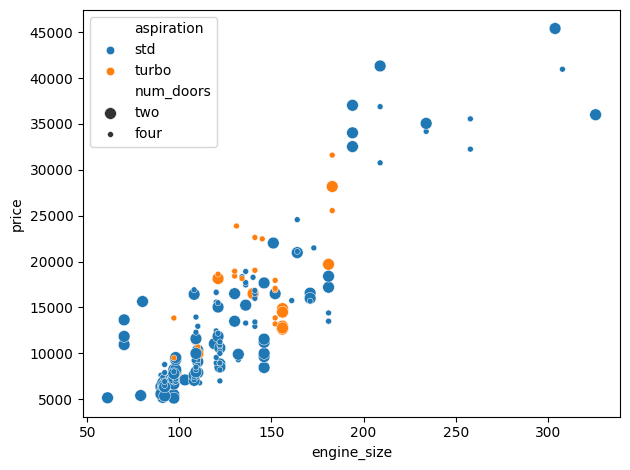

In [22]:
sns.scatterplot(
    data = cars_df,
    x='engine_size',
    y='price',
    hue='aspiration',
    size='num_doors'
    )
plt.tight_layout()
plt.show()

**Se puede observar que a menor tamaño de motor, tambien el precio del automovil es bajo. Además, los autos con motor turbo tienen un precio mas elevado. Por último, se puede ver que varios vehiculos con 2 puertas presentan los precios más altos.**

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

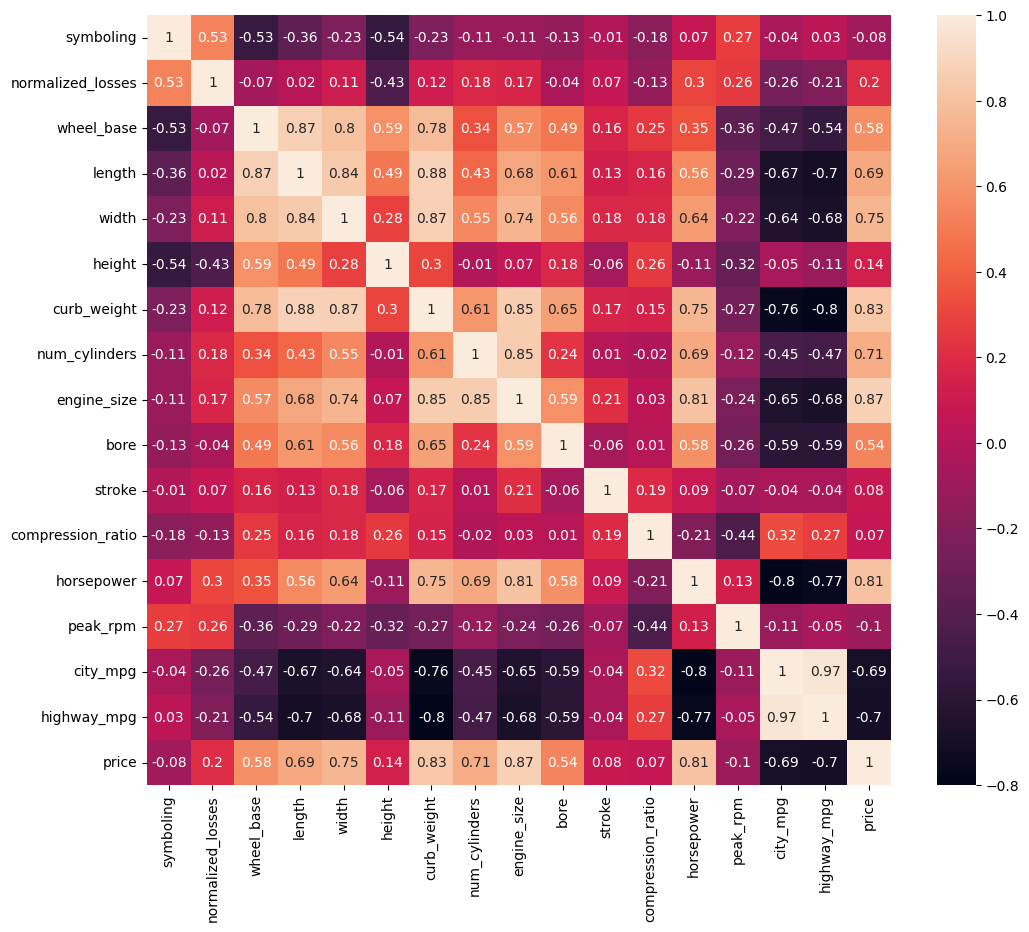

In [23]:
plt.figure(figsize = (12, 10))
sns.heatmap(round(cars_df.corr(numeric_only=True),2), annot = True)
plt.show()

**Las tres variables que más se correlacionan con el precio son: curb_weight, engine_size, horsepower**

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [24]:
#imputar valores nulos
cars_df[['normalized_losses']] = SimpleImputer(strategy='median').fit_transform(cars_df[['normalized_losses']])
cars_df[['price']] = SimpleImputer(strategy='median').fit_transform(cars_df[['price']])
cars_df[['horsepower']] = SimpleImputer(strategy='median').fit_transform(cars_df[['horsepower']])

**Con base en los histogramas creados en pasos anteriores, se puede observar que la distribución de estas variables está sesgada y es asimetrica. Por lo que, la mejor medida para imputar valores nulos es la mediana, dado que esta no se ve afectada por los outliers.**

In [25]:
#imputar valores nulos
cars_df[['stroke']] = SimpleImputer(strategy='mean').fit_transform(cars_df[['stroke']])
cars_df[['bore']] = SimpleImputer(strategy='mean').fit_transform(cars_df[['bore']])
cars_df[['peak_rpm']] = SimpleImputer(strategy='mean').fit_transform(cars_df[['peak_rpm']])

**Con base en los histogramas y las medidas de tendencia del paso 2 (la media y la mediana son valores muy cercanos), se puede observar que estas variables tienen distribuciones con poca asimetria. Por lo que, es posible usar la media como medida para imputar los valores nulos.**

In [27]:
x = cars_df[num_cols].drop('price', axis=1)
y = cars_df.loc[:, 'price']

In [28]:
total_components = x.shape[1]
total_components

16

In [29]:
escalar = StandardScaler()
x_scaled = escalar.fit_transform(x)
x_scaled[0:5]

array([[ 1.74347043, -0.17650339, -1.6907718 , -0.42652147, -0.84478235,
        -2.0204173 , -0.01456628, -0.35288699,  0.07444893,  0.51908935,
        -1.83940375, -0.28834891,  0.17330945, -0.263484  , -0.64655303,
        -0.54605874],
       [ 1.74347043, -0.17650339, -1.6907718 , -0.42652147, -0.84478235,
        -2.0204173 , -0.01456628, -0.35288699,  0.07444893,  0.51908935,
        -1.83940375, -0.28834891,  0.17330945, -0.263484  , -0.64655303,
        -0.54605874],
       [ 0.133509  , -0.17650339, -0.70859588, -0.23151305, -0.19056612,
        -0.54352748,  0.51488192,  1.50203181,  0.60404617, -2.40486235,
         0.6859198 , -0.28834891,  1.26376111, -0.263484  , -0.95301169,
        -0.69162706],
       [ 0.93848971,  1.36790124,  0.17369775,  0.2072559 ,  0.13654199,
         0.23594216, -0.42079745, -0.35288699, -0.43107572, -0.51724796,
         0.46215695, -0.03597283, -0.05492462,  0.78734611, -0.18686504,
        -0.10935377],
       [ 0.93848971,  1.36790124,  0

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [30]:
pca = PCA()
x_projected = pca.fit_transform(x_scaled)
x_projected = pd.DataFrame(x_projected, columns=['PC' + str(i + 1) for i in range(total_components)])
x_projected.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.919384,-2.406193,-0.402499,1.346231,-1.887584,1.174311,0.355801,0.288696,-1.080114,-0.355771,-0.469141,0.273889,-0.270899,0.363244,0.184951,0.004295
1,-0.919384,-2.406193,-0.402499,1.346231,-1.887584,1.174311,0.355801,0.288696,-1.080114,-0.355771,-0.469141,0.273889,-0.270899,0.363244,0.184951,0.004295
2,0.634947,-1.365444,0.893781,1.064648,1.808231,-0.756819,-0.512091,1.351798,-1.137038,-1.020624,0.502124,0.656220,0.190965,-0.011295,0.120130,-0.110875
3,-0.361340,-0.916692,0.443495,-1.508584,-0.194035,-0.786131,-0.006046,0.405769,0.286461,0.168863,0.039528,-0.022089,-0.081601,-0.391174,0.009578,0.053712
4,1.172646,-1.791997,0.183314,-1.085810,0.179242,-0.854495,-0.362352,0.869526,0.007601,-0.448777,-0.054254,-0.414795,-0.052693,0.079728,-0.198128,0.045940


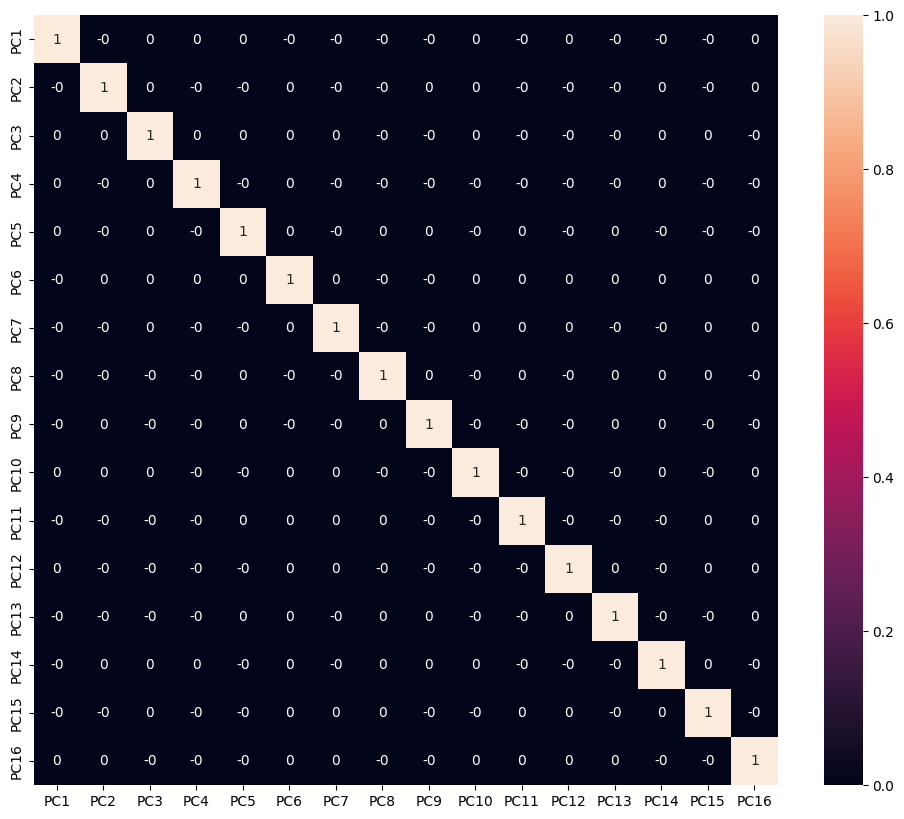

In [31]:
plt.figure(figsize = (12, 10))
sns.heatmap(round(x_projected.corr(numeric_only=True),2), annot = True)
plt.show()

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

In [32]:
print("The eigen values for the covariance matrix of our iris data are", list(np.round(pca.explained_variance_, decimals=2)))

The eigen values for the covariance matrix of our iris data are [np.float64(7.16), np.float64(2.88), np.float64(1.38), np.float64(1.03), np.float64(0.92), np.float64(0.77), np.float64(0.52), np.float64(0.44), np.float64(0.31), np.float64(0.25), np.float64(0.12), np.float64(0.1), np.float64(0.08), np.float64(0.06), np.float64(0.02), np.float64(0.02)]


In [33]:
for i in range(0, total_components):
  print("The percentage of variance explained by PC", i+1, "is", format(pca.explained_variance_ratio_[i]*100,'.0f'),'%')

The percentage of variance explained by PC 1 is 45 %
The percentage of variance explained by PC 2 is 18 %
The percentage of variance explained by PC 3 is 9 %
The percentage of variance explained by PC 4 is 6 %
The percentage of variance explained by PC 5 is 6 %
The percentage of variance explained by PC 6 is 5 %
The percentage of variance explained by PC 7 is 3 %
The percentage of variance explained by PC 8 is 3 %
The percentage of variance explained by PC 9 is 2 %
The percentage of variance explained by PC 10 is 2 %
The percentage of variance explained by PC 11 is 1 %
The percentage of variance explained by PC 12 is 1 %
The percentage of variance explained by PC 13 is 1 %
The percentage of variance explained by PC 14 is 0 %
The percentage of variance explained by PC 15 is 0 %
The percentage of variance explained by PC 16 is 0 %


In [34]:
np.cumsum(pca.explained_variance_ratio_)

array([0.4454729 , 0.62476823, 0.71064217, 0.77466788, 0.832144  ,
       0.88002188, 0.91263831, 0.9399166 , 0.95926513, 0.97480111,
       0.98228961, 0.98859068, 0.99373355, 0.99725849, 0.99881235,
       1.        ])

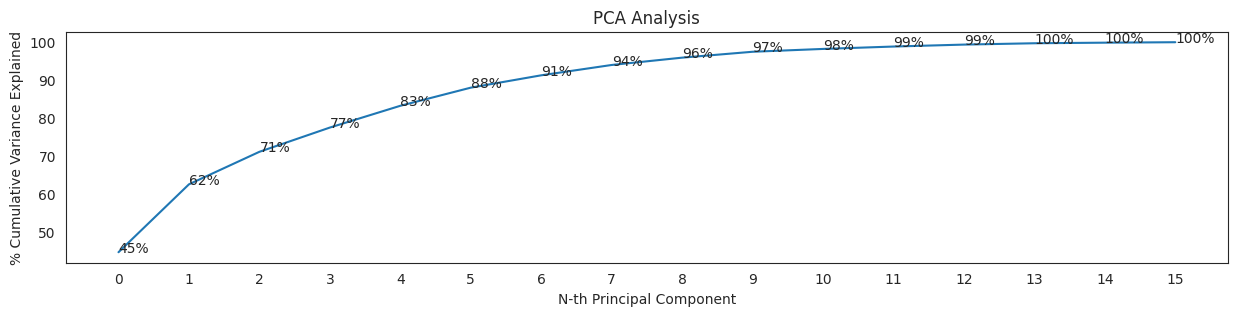

In [35]:
sns.set_style('white')

plt.figure(figsize=(15, 3))

plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.title('PCA Analysis')
plt.xlabel('N-th Principal Component')
plt.ylabel('% Cumulative Variance Explained')
plt.xticks(np.arange(0,total_components,1))

labels = np.cumsum(pca.explained_variance_ratio_)*100
for i in range(total_components):
  plt.text(i,labels[i],str(format(labels[i],'.0f'))+'%')

**7 componentes explican el 91% de la varianza total**

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

In [36]:
pca.components_

array([[-9.73293020e-02,  1.57894182e-02,  2.97810616e-01,
         3.37578546e-01,  3.34183486e-01,  1.13827055e-01,
         3.61965729e-01,  2.45105960e-01,  3.30123520e-01,
         2.62503886e-01,  5.28829505e-02,  1.59061441e-02,
         2.98491303e-01, -8.66535266e-02, -3.05849496e-01,
        -3.17500701e-01],
       [-4.02655803e-01, -3.30597746e-01,  2.64680492e-01,
         1.38841576e-01,  5.55009406e-02,  4.21462914e-01,
         2.26385128e-02, -1.13944100e-01, -8.12470431e-02,
         1.23800897e-03,  3.85235446e-02,  3.61171687e-01,
        -2.76186116e-01, -3.63654463e-01,  2.44753203e-01,
         1.95126756e-01],
       [ 2.64438226e-01,  3.06272026e-01, -3.22358142e-02,
        -4.58788259e-02,  1.07001929e-01, -2.84012860e-01,
         7.94529749e-02,  1.82826734e-01,  2.02087586e-01,
        -1.39733892e-01,  5.11310850e-01,  4.86075940e-01,
         1.17873690e-02, -2.58336666e-01,  1.98464998e-01,
         1.92187567e-01],
       [-8.76847908e-02, -3.64585242e

In [37]:
num_components = 7
pc_df = pd.DataFrame(abs(pca.components_[:num_components]), columns = x.columns, index=['Principal component {}'.format(i) for i in range(1, num_components + 1)])
pc_df

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
Principal component 1,0.097329,0.015789,0.297811,0.337579,0.334183,0.113827,0.361966,0.245106,0.330124,0.262504,0.052883,0.015906,0.298491,0.086654,0.305849,0.317501
Principal component 2,0.402656,0.330598,0.264680,0.138842,0.055501,0.421463,0.022639,0.113944,0.081247,0.001238,0.038524,0.361172,0.276186,0.363654,0.244753,0.195127
Principal component 3,0.264438,0.306272,0.032236,0.045879,0.107002,0.284013,0.079453,0.182827,0.202088,0.139734,0.511311,0.486076,0.011787,0.258337,0.198465,0.192188
Principal component 4,0.087685,0.364585,0.228687,0.196298,0.099152,0.184597,0.026978,0.558141,0.297769,0.026861,0.409673,0.011208,0.169514,0.274833,0.164501,0.154040
Principal component 5,0.364091,0.353329,0.006549,0.064795,0.013651,0.004081,0.042139,0.218366,0.096470,0.380476,0.584347,0.240960,0.101396,0.353257,0.005376,0.000720
Principal component 6,0.168667,0.492841,0.182391,0.082160,0.107107,0.213892,0.014509,0.353532,0.015572,0.507191,0.373719,0.095510,0.065524,0.278925,0.107861,0.078911
Principal component 7,0.120909,0.324796,0.104229,0.010758,0.140026,0.009610,0.061148,0.069652,0.072188,0.127303,0.145120,0.614056,0.224569,0.606021,0.034069,0.047154


/tmp/ipython-input-1920267559.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=pc_df.iloc[0:1],ci=None)


Text(0, 0.5, 'feature importance for PC1')

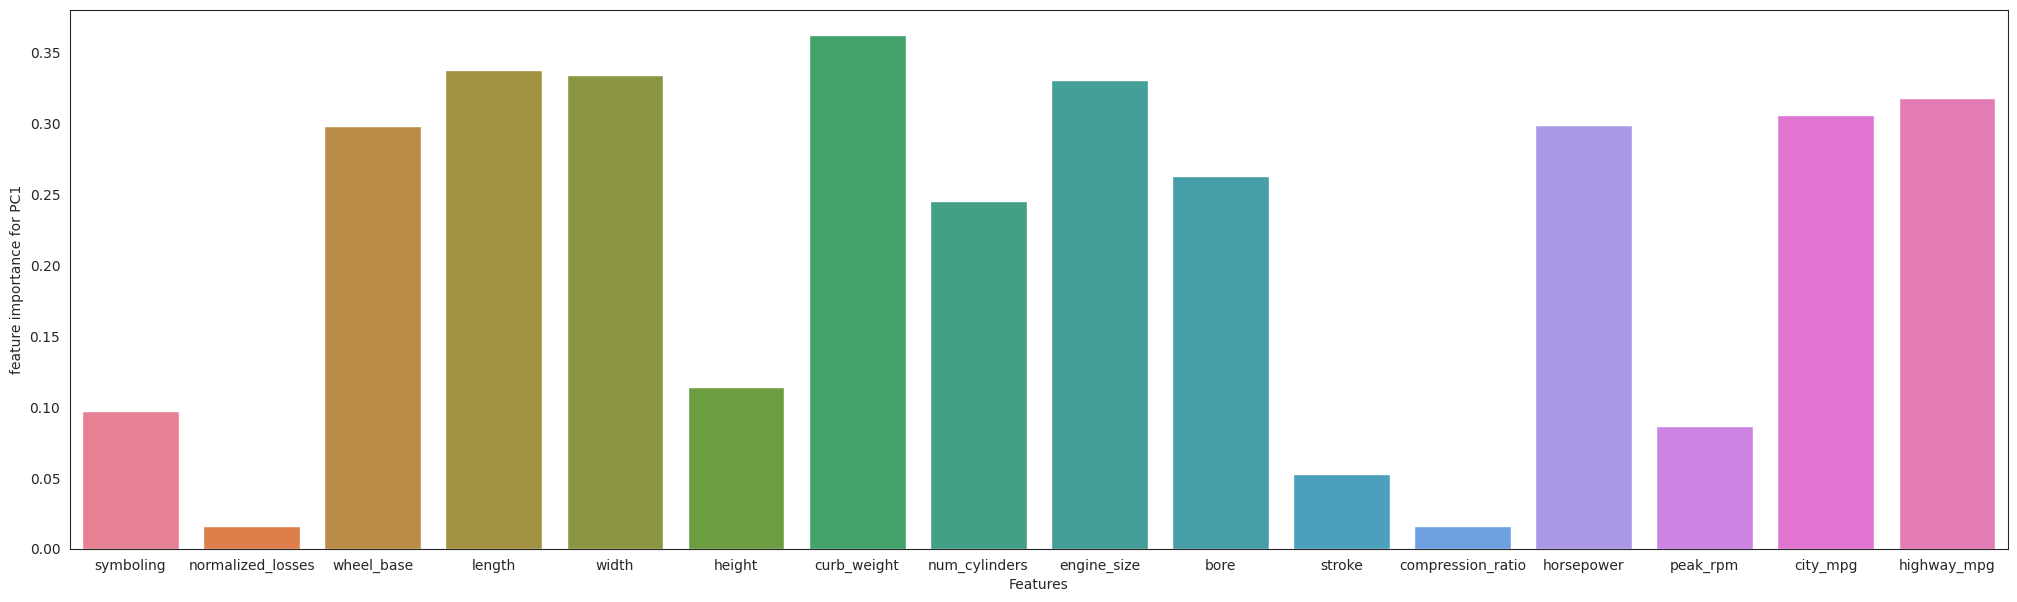

In [38]:
plt.figure(figsize=(25, 7))
sns.barplot(data=pc_df.iloc[0:1],ci=None)
plt.xlabel('Features')
plt.ylabel('feature importance for PC1')

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [39]:
encoder = OneHotEncoder(drop='first')
ohe = encoder.fit_transform(cars_df[cat_cols])
ohe_df = pd.DataFrame(ohe.toarray(), columns=encoder.get_feature_names_out(cat_cols))
ohe_df.head(3)

,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [40]:
new_data = x_projected.iloc[:,0:num_components]

new_data.columns = ['PC{}'.format(i) for i in range(1, num_components + 1)]
new_data = pd.concat([new_data, ohe_df, y], axis=1)
new_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.919384,-2.406193,-0.402499,1.346231,-1.887584,1.174311,0.355801,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13495.0
1,-0.919384,-2.406193,-0.402499,1.346231,-1.887584,1.174311,0.355801,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
2,0.634947,-1.365444,0.893781,1.064648,1.808231,-0.756819,-0.512091,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
3,-0.361340,-0.916692,0.443495,-1.508584,-0.194035,-0.786131,-0.006046,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13950.0
4,1.172646,-1.791997,0.183314,-1.085810,0.179242,-0.854495,-0.362352,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,2.572939,1.388218,-1.515206,-0.644362,0.092885,0.207942,0.663536,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16845.0
201,3.314234,0.835953,-1.741035,-0.555095,0.174733,0.465148,0.637562,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19045.0
202,3.677842,0.471642,-1.791561,0.756047,0.489600,-1.015895,0.593807,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,21485.0
203,2.546726,3.037089,1.733490,0.329092,0.752406,-1.625608,1.370991,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,22470.0


In [41]:
new_data.to_csv('automobile_afterPCA.csv')